---
title: Homework 02 Submission
date: 2025-02-16
authors:
  - name: Nico O'Neill 
    affiliations:
      - Syracuse University
numbering:
  heading_1: true
  heading_2: true
  heading_3: true
---

In [1]:
%matplotlib widget
from ipywidgets import *
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use('dark_background')

fontsize = 14
mpl.rcParams.update(
    {
        "text.usetex": True,
        "figure.figsize": (9, 6),
        "figure.autolayout": True,
        "font.family": "serif",
        "font.serif": "georgia",
        # 'mathtext.fontset': 'cm',
        "lines.linewidth": 1.5,
        "font.size": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fancybox": True,
        "legend.fontsize": fontsize,
        "legend.framealpha": 0.7,
        "legend.handletextpad": 0.5,
        "legend.labelspacing": 0.2,
        "legend.loc": "best",
        "axes.edgecolor": "#b0b0b0",
        "grid.color": "#707070",  # grid color"
        "xtick.color": "#b0b0b0",
        "ytick.color": "#b0b0b0",
        "savefig.dpi": 80,
        "pdf.compression": 9,
    }
)

## Question 1 Solution:
\begin{align}
\frac{dN_3}{dt} &= -\gamma_{32} N_3 + K(N_0 - N_3) \\
\frac{dN_2}{dt} &= \gamma_{32} N_3 - \gamma_{21} N_2 - \gamma_{20} N_2 \\
\frac{dN_1}{dt} &= \gamma_{21} N_2 - \gamma_{10} N_1 \\
\frac{dN_0}{dt} &= - K(N_0 - N_3) + \gamma_{10} N_1 + \gamma_{20} N_2 \\
\end{align}
For population inversion, we require that:
\begin{align}
N_2 &> N1 \\
\gamma_{21} N_2 &= \gamma_{10} N_1 \\
\gamma_{10} &> \gamma_{21}
\end{align}
In words, we need the rate at which the first state loses electrons to the zero state to be greater than the rate at which the second state loses electrons to the first state. 

## Question 2 Solution:
\begin{align}
E_{\gamma} &= hv \\
E_{\gamma} &= \frac{hc}{\lambda} \\
E_{max} &= N_{\gamma} E_{\gamma} \\
E_{max} &= nV\frac{hc}{\lambda} \\
E_{max} &= n\pi r^2 L \frac{hc}{\lambda} \\
E_{max} &= 2*10^{19} * \pi * 0.5^2 * 7.5 * \frac{hc}{694 * 10^{-9}} \\
E_{max} &= 33.74 J \\
P_{peak} &= \frac{E_{max}}{\delta t} \\
P_{peak} &= \frac{33.74 J }{50 ns} \\
P_{peak} &= 674876571.7 W
\end{align}

## Question 2.1 Solution:
\begin{align}
I &= \frac{P_{peak}}{A}\\
I &= \frac{0.6 GW}{\pi * 0.05^2}\\
I &= 8.6 * 10^{10}
\end{align}

## Question 3.1 Solution:
We want to write each contributing electric field as a series of round trip fields, so we take $\phi$ to be the round trip phase:
\begin{align}
E_0 &= t_1 E_{in}\\
E_1 &= E_0 (r_1 r_2 e^{-i\phi}) \\
E_2 &= E_1 (r_1 r_2 e^{-i\phi}) \\
E_n &= E_0 x^n \\
\end{align}
where $x = r_1 r_2 e^{-i\phi}$
By the geometric series,
\begin{align}
E_{cav} &= \sum E_n \\
E_{cav} &= E_0 \sum x^n \\
E_{cav} &= E_0 (\frac{1}{1-x})\\
\end{align}
This is possible because $|x| < 1$ which we know is true because $|r_1 r_2| < 1$.
\begin{align}
E_{cav} &= E_{in} (\frac{t_1}{1- r_1 r_2 e^{-2ikL}})\\
\end{align}

## Question 3.2 Solution:

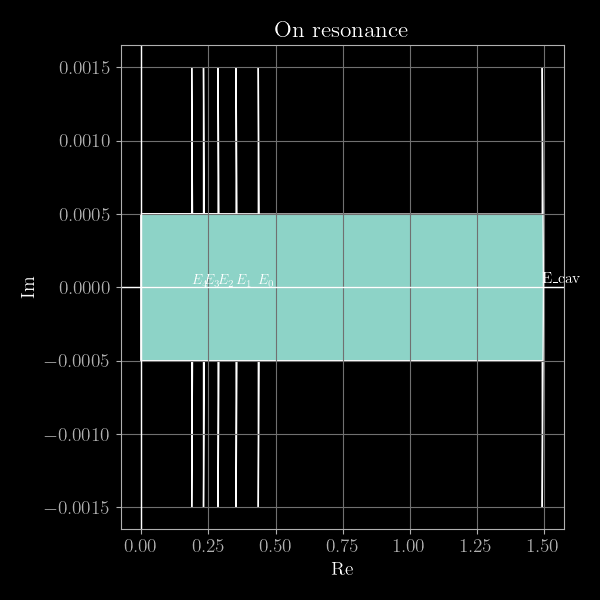

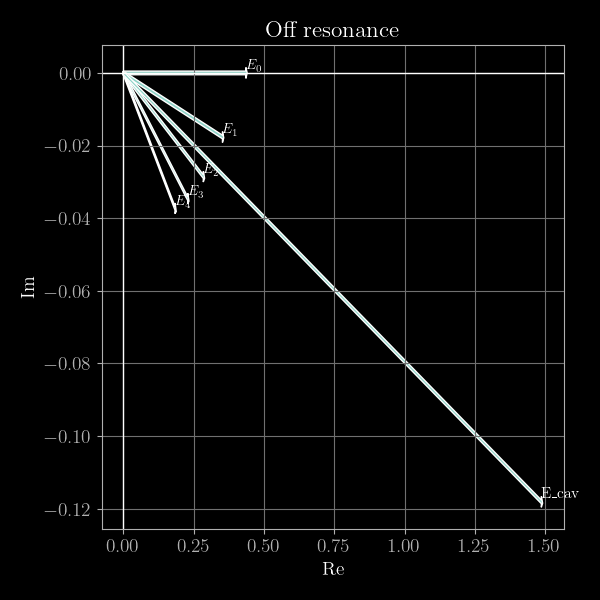

In [6]:
## These plots look bad but I don't know why, it's still clear whats happening though...

# Cavity Parameters
r1 = 0.9
r2 = 0.9
t1 = np.sqrt(1 - r1**2)   # lossless mirrors
Ein = 1.0 + 0j

N = 5   # number of E_n

def phasors(phi_rt, N=N):
    x = r1 * r2 * np.exp(-1j * phi_rt) 
    En = np.array([t1 * Ein * (x**n) for n in range(N)])
    return En

def plot_phasors(phi_rt, title, N=N):
    En = phasors(phi_rt, N=N)
    Ecav = En.sum()

    fig, ax = plt.subplots(figsize=(6, 6))

    # plot various E_n
    for n, e in enumerate(En):
        ax.arrow(0, 0, e.real, e.imag)
        ax.text(e.real, e.imag, f"$E_{n}$", fontsize=10, ha='left', va='bottom')

    # plot E_cav
    ax.arrow(0, 0, Ecav.real, Ecav.imag)
    ax.text(Ecav.real, Ecav.imag, "E_{cav}", fontsize=11, ha='left', va='bottom')

    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.grid(True)
    ax.set_title(title)
    ax.set_xlabel("Re")
    ax.set_ylabel("Im")
    
    plt.show()

# On resonance
plot_phasors(
    phi_rt=0.0,
    title="On resonance",
    N=N
)

# Off resonance
phi_small = 0.05
plot_phasors(
    phi_rt=phi_small,
    title="Off resonance",
    N=N
)

## Problem 3.3 Solutions:
\begin{align}
\tau_{rt} &= \frac{2L}{c} \\
E_n &= E_{in} t_1 x^n \\
n(t) &= \frac{t}{\tau_{rt}} \\
E_{cav} &= \sum t_1 E_{in} x^{n} \\
E_{cav} &= t_1 E_{in} \frac{1 - (r_1 r_2)^{n+1}}{1 - r_1 r_2}
\end{align}
For part 4, we need to approximate by normalizing for the steady state limit:
\begin{align}
E_{ss} &= \frac{t_1}{1 - x} E_{in} \\
1 - x^{n+1} &= \frac{E_{cav}}{E_{ss}} \\
x^{n+1} &= e^{(n+1)ln(x)} \\
&= e^{\frac{t}{\tau_{rt}}ln(x)} \\
\tau_{s} &= - \frac{\tau_{rt}}{ln(r_1 r_2)} \\
v_p &= \frac{1}{2\pi \tau_s} \\
&= - \frac{ln(r_1 r_2)}{2\pi \tau_{rt}}
\end{align}

## Problem 4 Solution: 
\begin{align}
F &= \frac{FSR}{FWHM} \\
F &= \frac{\frac{c}{2L}}{\frac{c}{\pi L}arcsin(\frac{1- r_1 r_2}{2 \sqrt{r_1 r_2}})} \\
&= \frac{\frac{\pi}{2}}{arcsin(\frac{1- r_1 r_2}{2 \sqrt{r_1 r_2}})} \\
&= \frac{\pi \sqrt(r_1 r_2)}{1 - r_1 r_2}
\end{align}
We can assume $\sqrt(r_1 r_2) = 1$ in the high finesse limit, since losses are minimal. Using the definition of loss,
\begin{align}
r &= \sqrt(1 - t_1 -L) \\
r_1 r_2 &= 1 - \frac{L}{2} \\
F &= \frac{2\pi}{L}
\end{align}

## Problem 5 Solution:
\begin{align}
G_{cav} = \frac{T_1}{(1-\sqrt{R_1 R_2})^2}
\end{align}
For a critically coupled cavity,
\begin{align}
L &= 2T_1 \\
F &= \frac{\pi}{T_1} \\
1-\sqrt{R_1 R_2} \approx T_1 \\
G_{cav} &= \frac{1}{T_1} \\
F &= \pi G_{cav}
\end{align}
For an over coupled cavity, we assume $T_1 >> L$, since $r_2 \approx 1$, for an extreme case:
\begin{align}
L &= T_1 \\
F &= \frac{2\pi}{T_1} \\
1-\sqrt{R_1 R_2} \approx \frac{T_1}{2} \\
G_{cav} &= \frac{4}{T_1} \\
F &= 2\pi G_{cav}
\end{align}

## Problem 6 Solution:
\begin{align}
\frac{E_r}{E_i} = \frac{r_1 - r_2 e^{-i(\phi + \delta_0)}}{1 - r_1 r_2 e^{-i(\phi + \delta_0)}}
\end{align}
For the specific case given, we can simplify this expression to:
\begin{align}
\frac{E_r}{E_i} = \frac{r_1 - e^{-i\phi}}{1 - r_1 e^{-i\phi}}
\end{align}

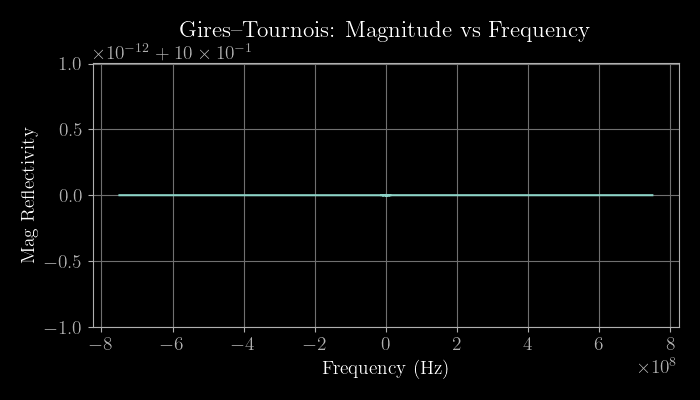

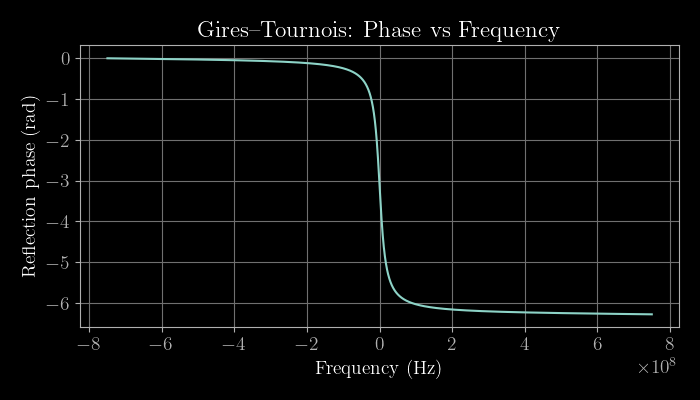

In [3]:
# params
c = 299792458.0  # m/s
L = 0.10  # m
R1 = 0.9   
R2 = 1.0  # r_2 = 1

r1 = np.sqrt(R1)
r2 = np.sqrt(R2)

FSR = c / (2 * L)

span = 0.5 * FSR
f = np.linspace(0 - span, 0 + span, 5000)

# phase rt
phi = 2 * np.pi * (f - 0) / FSR # 0 is the resonant point

# reflectivity
r = (r1 - r2 * np.exp(-1j * phi)) / (1 - r1 * r2 * np.exp(-1j * phi))

# magnitude plot
plt.figure(figsize=(7,4))
plt.plot(f, np.abs(r))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Mag Reflectivity")
plt.title("Gires–Tournois: Magnitude vs Frequency")
plt.grid(True)
plt.show()

# phase plot
phase = np.unwrap(np.angle(r))
plt.figure(figsize=(7,4))
plt.plot(f, phase)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Reflection phase (rad)")
plt.title("Gires–Tournois: Phase vs Frequency")
plt.grid(True)
plt.show()


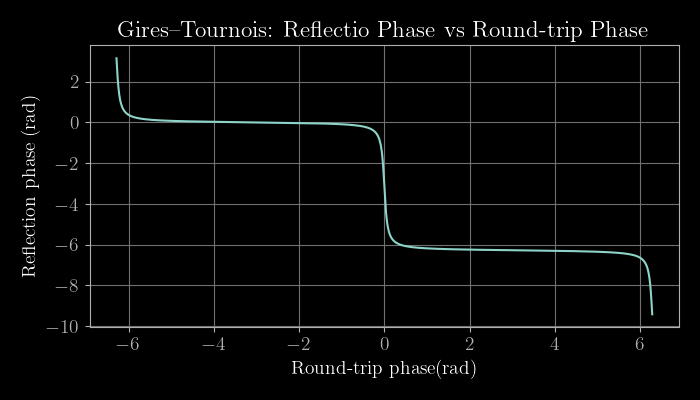

In [4]:
phi = np.linspace(-2*np.pi, 2*np.pi, 5000)

# reflectivity
r = (r1 - r2 * np.exp(-1j * phi)) / (1 - r1 * r2 * np.exp(-1j * phi))

# reflection phase
theta = np.unwrap(np.angle(r))

# phase v roundtrip phase
plt.figure(figsize=(7,4))
plt.plot(phi, theta)
plt.xlabel("Round-trip phase(rad)")
plt.ylabel("Reflection phase (rad)")
plt.title("Gires–Tournois: Reflectio Phase vs Round-trip Phase")
plt.grid(True)
plt.show()